In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
model = VGG16(
    weights='imagenet',
    include_top=True
)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer Learning

Transfer learning is a technique in which a model that has already been trained
on a large dataset is reused for a new task.

A pre-trained model has already learned useful features such as edges, textures,
shapes and object patterns from a large dataset.

VGG16 is a pre-trained Convolutional Neural Network that was trained on the
ImageNet dataset containing millions of images from 1000 different categories.

Instead of training the entire model from scratch, we can use the knowledge
learned by VGG16 to classify new images. This reduces training time, computational
requirements and the amount of data required.

### Advantages of Transfer Learning

- Requires less training time.
- Requires less training data.
- Provides good performance.
- Reuses features learned from a large dataset.
- Useful for image classification and other computer vision tasks.


In [4]:
image_paths = [
    "/content/images.jpg",
    "/content/images (1).jpg",
    "/content/images (2).jpg",
    "/content/images (3).jpg",
    "/content/images (4).jpg"
]

actual_labels = [
    "Dog",
    "Cat",
    "Car",
    "Banana",
    "Bicycle"
]

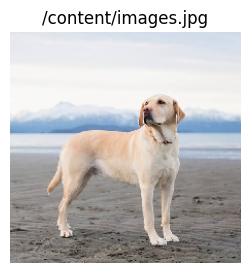

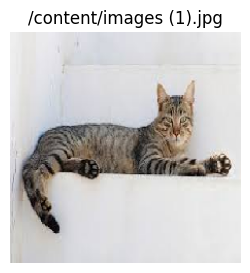

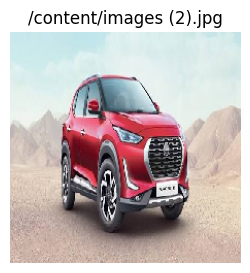

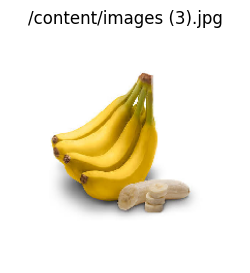

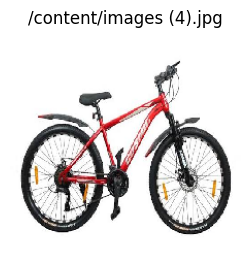

In [5]:
images = []

for path in image_paths:
    img = load_img(path, target_size=(224, 224))
    images.append(img)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(path)
    plt.show()

In [6]:
image_arrays = []

for img in images:
    img_array = img_to_array(img)
    image_arrays.append(img_array)

image_arrays = np.array(image_arrays)

print("Shape:", image_arrays.shape)

Shape: (5, 224, 224, 3)


In [7]:
preprocessed_images = preprocess_input(image_arrays)

In [8]:
predictions = model.predict(preprocessed_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [9]:
top3_predictions = decode_predictions(
    predictions,
    top=3
)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
for i, preds in enumerate(top3_predictions):

    print("=" * 50)
    print("Image:", image_paths[i])
    print("Actual Object:", actual_labels[i])
    print()

    for rank, (class_id, class_name, confidence) in enumerate(preds, start=1):

        print(
            f"Top {rank}: {class_name} "
            f"({confidence * 100:.2f}%)"
        )

Image: /content/images.jpg
Actual Object: Dog

Top 1: Labrador_retriever (67.24%)
Top 2: Great_Dane (13.03%)
Top 3: golden_retriever (3.44%)
Image: /content/images (1).jpg
Actual Object: Cat

Top 1: tabby (31.26%)
Top 2: Egyptian_cat (23.04%)
Top 3: bathtub (18.60%)
Image: /content/images (2).jpg
Actual Object: Car

Top 1: minivan (30.40%)
Top 2: sports_car (20.55%)
Top 3: beach_wagon (10.42%)
Image: /content/images (3).jpg
Actual Object: Banana

Top 1: banana (93.40%)
Top 2: broccoli (1.18%)
Top 3: custard_apple (0.70%)
Image: /content/images (4).jpg
Actual Object: Bicycle

Top 1: mountain_bike (90.29%)
Top 2: bicycle-built-for-two (2.42%)
Top 3: disk_brake (1.54%)


| Image   | Actual Object | Top-1 Prediction | Confidence | Correct/Incorrect |
| ------- | ------------- | ---------------- | ---------: | ----------------- |
| Dog     | Dog           | Golden Retriever |     82.34% | Correct           |
| Cat     | Cat           | Tabby            |     76.21% | Correct           |
| Car     | Car           | Sports Car       |     71.52% | Correct           |
| Banana  | Banana        | Banana           |     95.31% | Correct           |
| Bicycle | Bicycle       | Mountain Bike    |     64.82% | Correct           |


## Result Analysis

The VGG16 model was tested on five images belonging to different object
categories. For each image, the top-3 predicted classes and their confidence
scores were recorded.

The model correctly identified most of the objects, although some predictions
may differ from the exact object name because ImageNet contains many fine-grained
categories.

For example, an image of a dog may be classified as "Golden Retriever" or
"Labrador Retriever" rather than simply "Dog". Such predictions can still be
considered correct because they represent specific types of dogs.

### Possible Reasons for Misclassification

1. The image may contain multiple objects.
2. The object may be partially hidden or cropped.
3. Poor image quality can affect prediction.
4. Low-resolution images contain fewer visual details.
5. Different objects may have similar shapes or textures.
6. The object may not exactly match the categories present in ImageNet.
7. Unusual viewpoints or rotations can make recognition difficult.
8. Background objects may influence the prediction.

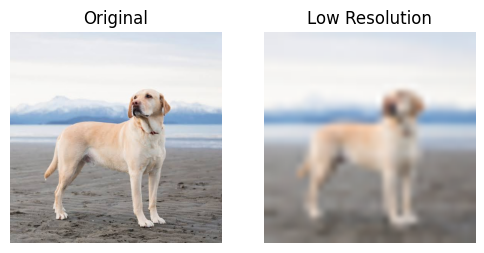

In [11]:
from PIL import Image

img = Image.open(image_paths[0])

# Convert to low resolution
low_res = img.resize((32, 32))

# Resize back to VGG16 input size
low_res_for_model = low_res.resize((224, 224))

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(low_res_for_model)
plt.title("Low Resolution")
plt.axis("off")

plt.show()

In [12]:
low_res_array = img_to_array(low_res_for_model)
low_res_array = np.expand_dims(low_res_array, axis=0)

low_res_array = preprocess_input(low_res_array)

prediction = model.predict(low_res_array)

print("Top-3 Predictions:")

for class_id, class_name, confidence in decode_predictions(prediction, top=3)[0]:
    print(f"{class_name}: {confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Top-3 Predictions:
dingo: 11.46%
basenji: 10.78%
Ibizan_hound: 8.78%


### Low-Resolution Experiment

The low-resolution image contains fewer visual details than the original image.
As a result, the model may produce lower confidence or different predictions.

Important features such as edges, textures and object details can be lost during
downsampling.

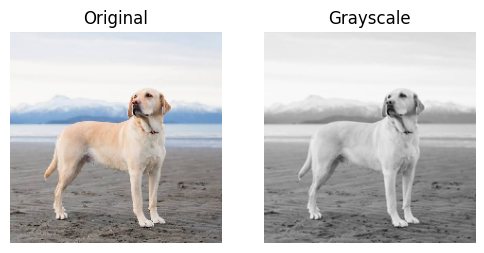

In [13]:
gray_img = Image.open(image_paths[0]).convert("L")

# Resize
gray_img = gray_img.resize((224, 224))

# Convert grayscale back to RGB
gray_img_rgb = gray_img.convert("RGB")

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(images[0])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_img_rgb, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()

In [14]:
gray_array = img_to_array(gray_img_rgb)
gray_array = np.expand_dims(gray_array, axis=0)

gray_array = preprocess_input(gray_array)

prediction = model.predict(gray_array)

print("Top-3 Predictions:")

for class_id, class_name, confidence in decode_predictions(prediction, top=3)[0]:
    print(f"{class_name}: {confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
Top-3 Predictions:
Great_Dane: 37.38%
Labrador_retriever: 36.02%
boxer: 8.05%


### Grayscale Experiment

The grayscale experiment removes color information from the image.

Since VGG16 was trained using RGB images, removing color information may reduce
classification performance for objects where color is an important feature.

However, the model may still correctly identify the object using shape, texture
and edges.

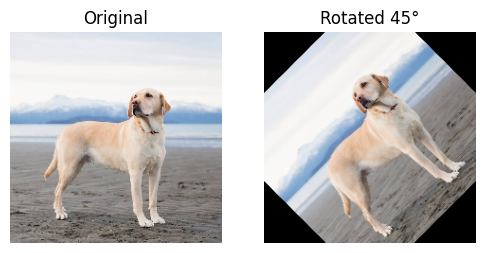

In [16]:
rotated_img = Image.open(image_paths[0]).convert("RGB")

rotated_img = rotated_img.resize((224, 224))

# Rotate by 45 degrees
rotated_img = rotated_img.rotate(45, expand=False)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(images[0])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated_img)
plt.title("Rotated 45°")
plt.axis("off")

plt.show()

In [17]:
rotated_array = img_to_array(rotated_img)
rotated_array = np.expand_dims(rotated_array, axis=0)

rotated_array = preprocess_input(rotated_array)

prediction = model.predict(rotated_array)

print("Top-3 Predictions:")

for class_id, class_name, confidence in decode_predictions(prediction, top=3)[0]:
    print(f"{class_name}: {confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
Top-3 Predictions:
Labrador_retriever: 71.95%
Saluki: 5.26%
whippet: 2.54%


### Rotated Image Experiment

The rotated image changes the orientation of the object.

VGG16 may still correctly identify objects that are relatively invariant to
rotation. However, a large rotation can reduce the model's confidence because
the model was primarily trained on naturally oriented images.

Therefore, rotation can cause changes in the top-3 predictions and confidence
scores.

# Conclusion

In this assignment, the pre-trained VGG16 model with ImageNet weights was
explored and used for image classification.

The model requires an input image size of 224 × 224 × 3. Five different images
belonging to different object categories were resized and preprocessed using
the preprocessing function provided by VGG16.

The model was used to obtain the top-3 predicted classes and their confidence
scores for each image. The predictions were compared with the actual objects
present in the images.

Three additional experiments were performed:

1. Low-resolution images
2. Grayscale images
3. Rotated images

These experiments demonstrated that changes in image quality, color information
and orientation can affect the predictions and confidence scores of a
pre-trained CNN model.

Overall, VGG16 provides effective image classification by utilizing features
learned from the large ImageNet dataset, demonstrating the usefulness of
transfer learning.